# 03 — Machine Learning Model Experimentation
## Rx Drug MMIX Analysis

This notebook builds and benchmarks three machine learning models to predict pharmaceutical
sales from marketing mix variables. The ML family serves as a predictive benchmark against
the parametric models from Notebook 02.

**Why ML models alongside parametric?**
- ML models can capture nonlinearities and interactions automatically without manual specification
- They provide an upper bound on achievable predictive accuracy for this dataset
- The gap between ML and parametric performance helps quantify the cost of interpretability

**Three ML models:**
1. Random Forest Regressor — robust ensemble baseline for small tabular data
2. Gradient Boosting Regressor — strong sequential ensemble, typically best on structured data
3. ElasticNet Regression — regularized linear model that bridges parametric and ML families

**Train/test split:** Same time-based split as Notebook 02 (train 2013-2020, validation 2021-2022, test 2023-2024)

**Units:** Sales ($B), Detailing ($M), DTCA ($K)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load Processed Data

In [2]:
df = pd.read_csv("data/processed_eda.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (207, 10)
Columns: ['class', 'agent', 'year', 'detailing', 'direct_to_consumer_ad', 'actual_sales', 'log_sales', 'log_detailing', 'log_dtca', 'dtca_zero']


,class,agent,year,detailing,direct_to_consumer_ad,actual_sales,log_sales,log_detailing,log_dtca,dtca_zero
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083,1.3631,3.8040,0.0000,1
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235,2.7552,3.7530,0.0000,1
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120,0.6482,3.1513,0.0000,1
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677,2.5070,4.0684,0.0000,1
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600,3.0568,4.4489,0.0000,1


## 2. Time-Based Data Split

Same split as Notebook 02 to ensure fair comparison with parametric models.

In [3]:
train_df = df[df["year"] <= 2020].copy()
valid_df = df[(df["year"] >= 2021) & (df["year"] <= 2022)].copy()
test_df  = df[df["year"] >= 2023].copy()

print(f"Train: {train_df.shape[0]} rows ({sorted(train_df['year'].unique())})")
print(f"Validation: {valid_df.shape[0]} rows ({sorted(valid_df['year'].unique())})")
print(f"Test: {test_df.shape[0]} rows ({sorted(test_df['year'].unique())})")

Train: 119 rows ([np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)])
Validation: 44 rows ([np.int64(2021), np.int64(2022)])
Test: 44 rows ([np.int64(2023), np.int64(2024)])


## 3. Feature Preparation

ML models require numeric input. We one-hot encode the categorical variables (class, agent)
and pass numeric features directly. We include both raw and log-transformed marketing
variables so the tree models can discover the appropriate functional form on their own.

The target is `actual_sales` on the original scale. Unlike the parametric models which
operate in log space, tree-based models handle skewed targets reasonably well without
transformation. We predict on the original dollar scale for direct comparability.

In [4]:
feature_cols = ["year", "detailing", "direct_to_consumer_ad",
                "log_detailing", "log_dtca", "dtca_zero"]
cat_cols = ["class", "agent"]
target = "actual_sales"

# One-hot encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(train_df[cat_cols])

def prepare_features(data):
    """Combine numeric features with one-hot encoded categoricals."""
    numeric = data[feature_cols].values
    encoded = encoder.transform(data[cat_cols])
    feature_names = feature_cols + list(encoder.get_feature_names_out(cat_cols))
    X = np.hstack([numeric, encoded])
    return X, feature_names

X_train, feature_names = prepare_features(train_df)
y_train = train_df[target].values

X_valid, _ = prepare_features(valid_df)
y_valid = valid_df[target].values

X_test, _ = prepare_features(test_df)
y_test = test_df[target].values

print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Features: {feature_names[:10]} ... ({len(feature_names)} total)")

Feature matrix shape: (119, 30)
Number of features: 30
Features: ['year', 'detailing', 'direct_to_consumer_ad', 'log_detailing', 'log_dtca', 'dtca_zero', 'class_PPI', 'class_SSRI', 'class_Statin', 'agent_  Aciphex'] ... (30 total)


## 4. Evaluation Utilities

In [5]:
def evaluate(y_true, y_pred, model_name, dataset_name):
    """Compute metrics on original dollar scale."""
    y_pred = np.maximum(y_pred, 0)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    mask = y_true > 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return pd.DataFrame({
        "model": [model_name],
        "dataset": [dataset_name],
        "RMSE": [round(rmse, 4)],
        "MAE": [round(mae, 4)],
        "R2": [round(r2, 4)],
        "MAPE": [round(mape, 2)]
    })


def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    lims = [0, max(y_true.max(), y_pred.max()) * 1.05]
    plt.plot(lims, lims, "--", color="gray", linewidth=1)
    plt.xlabel("Actual Sales ($B)")
    plt.ylabel("Predicted Sales ($B)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

print("Evaluation utilities ready.")

Evaluation utilities ready.


## 5. Time-Aware Cross-Validation for Hyperparameter Selection

Standard K-fold cross-validation would leak future data into training. Instead, we use
rolling year-based validation within the training period:

- Fold 1: train on 2013-2016, validate on 2017
- Fold 2: train on 2013-2017, validate on 2018
- Fold 3: train on 2013-2018, validate on 2019
- Fold 4: train on 2013-2019, validate on 2020

For each model, we test a small number of sensible configurations (not an exhaustive grid)
and pick the one with the lowest average validation RMSE across folds.

In [6]:
def rolling_cv_folds(data, min_train_end=2016, max_train_end=2019):
    """Generate time-based CV fold indices."""
    folds = []
    for end_year in range(min_train_end, max_train_end + 1):
        tr_idx = data[data["year"] <= end_year].index
        va_idx = data[data["year"] == end_year + 1].index
        if len(tr_idx) > 0 and len(va_idx) > 0:
            folds.append((tr_idx, va_idx))
    return folds

cv_folds = rolling_cv_folds(train_df)
print(f"Number of CV folds: {len(cv_folds)}")
for i, (tr, va) in enumerate(cv_folds):
    tr_years = sorted(train_df.loc[tr, "year"].unique())
    va_years = sorted(train_df.loc[va, "year"].unique())
    print(f"  Fold {i+1}: train {tr_years[0]}-{tr_years[-1]} ({len(tr)} rows), validate {va_years[0]} ({len(va)} rows)")

Number of CV folds: 4
  Fold 1: train 2013-2016 (46 rows), validate 2017 (15 rows)
  Fold 2: train 2013-2017 (61 rows), validate 2018 (17 rows)
  Fold 3: train 2013-2018 (78 rows), validate 2019 (20 rows)
  Fold 4: train 2013-2019 (98 rows), validate 2020 (21 rows)


In [7]:
def cv_evaluate(model_class, param_configs, model_name):
    """Evaluate a small set of configurations using rolling CV."""
    rows = []
    for config in param_configs:
        fold_rmses = []
        for tr_idx, va_idx in cv_folds:
            tr_data = train_df.loc[tr_idx]
            va_data = train_df.loc[va_idx]

            X_tr, _ = prepare_features(tr_data)
            y_tr = tr_data[target].values
            X_va, _ = prepare_features(va_data)
            y_va = va_data[target].values

            model = model_class(**config)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_va)
            rmse = np.sqrt(mean_squared_error(y_va, pred))
            fold_rmses.append(rmse)

        rows.append({
            "model": model_name,
            "params": str(config),
            "cv_rmse_mean": round(np.mean(fold_rmses), 4),
            "cv_rmse_std": round(np.std(fold_rmses), 4)
        })

    return pd.DataFrame(rows).sort_values("cv_rmse_mean")

print("CV evaluation function ready.")

CV evaluation function ready.


## 6. ML Model 1: Random Forest

Random Forest averages many decision trees trained on bootstrap samples. It handles
nonlinearities and interactions naturally without specification. We test a focused
set of configurations rather than an exhaustive grid, since the dataset is small (207 rows)
and large grids add computation without meaningful improvement.

In [8]:
rf_configs = [
    {"n_estimators": 200, "max_depth": 5, "min_samples_leaf": 2, "random_state": 42},
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 2, "random_state": 42},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 4, "random_state": 42},
    {"n_estimators": 500, "max_depth": 5, "min_samples_leaf": 4, "random_state": 42},
    {"n_estimators": 500, "max_depth": 8, "min_samples_leaf": 2, "random_state": 42},
]

rf_cv = cv_evaluate(RandomForestRegressor, rf_configs, "Random Forest")
display(rf_cv)

best_rf_params = eval(rf_cv.iloc[0]["params"])
print(f"\nBest RF config: {best_rf_params}")

,model,params,cv_rmse_mean,cv_rmse_std
0,Random Forest,"{'n_estimators': 200, 'max_depth': 5, 'min_sam...",8.4092,1.4191
1,Random Forest,"{'n_estimators': 300, 'max_depth': 8, 'min_sam...",8.5062,1.4004
4,Random Forest,"{'n_estimators': 500, 'max_depth': 8, 'min_sam...",8.5341,1.4106
2,Random Forest,"{'n_estimators': 300, 'max_depth': None, 'min_...",9.5646,1.3556
3,Random Forest,"{'n_estimators': 500, 'max_depth': 5, 'min_sam...",9.6019,1.3026



Best RF config: {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 2, 'random_state': 42}


,model,dataset,RMSE,MAE,R2,MAPE
0,M1: Random Forest,validation,5.5282,4.5064,0.8566,896.2600
1,M1: Random Forest,test,5.2544,4.1924,0.8582,860.8800


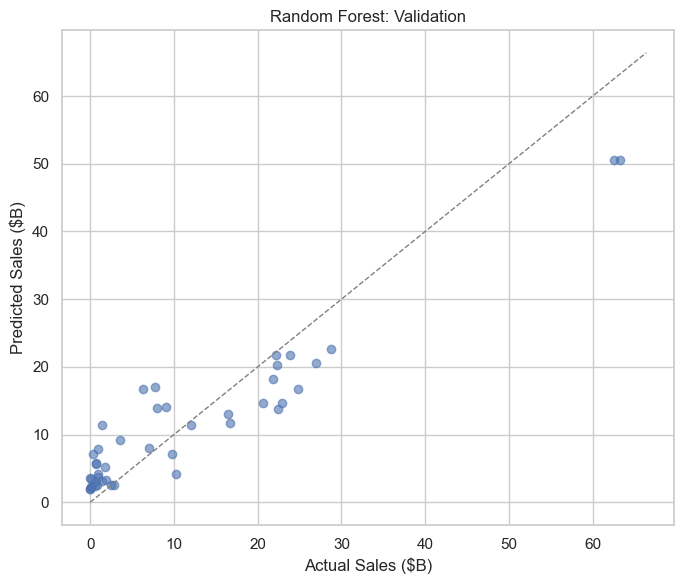

In [9]:
# Fit best Random Forest on full training set
rf_model = RandomForestRegressor(**best_rf_params)
rf_model.fit(X_train, y_train)

rf_pred_valid = rf_model.predict(X_valid)
rf_pred_test = rf_model.predict(X_test)

results = []
results.append(evaluate(y_valid, rf_pred_valid, "M1: Random Forest", "validation"))
results.append(evaluate(y_test, rf_pred_test, "M1: Random Forest", "test"))

display(pd.concat(results, ignore_index=True))
plot_actual_vs_predicted(y_valid, rf_pred_valid, "Random Forest: Validation")

## 7. ML Model 2: Gradient Boosting

Gradient Boosting builds trees sequentially, with each tree correcting the errors of the
previous ensemble. It typically outperforms Random Forest on structured tabular data and
is considered the standard ML baseline for this type of problem.

In [10]:
gbr_configs = [
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3, "subsample": 0.8, "random_state": 42},
    {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 3, "subsample": 0.9, "random_state": 42},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4, "subsample": 0.8, "random_state": 42},
    {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 3, "subsample": 0.9, "random_state": 42},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 3, "subsample": 0.8, "random_state": 42},
]

gbr_cv = cv_evaluate(GradientBoostingRegressor, gbr_configs, "Gradient Boosting")
display(gbr_cv)

best_gbr_params = eval(gbr_cv.iloc[0]["params"])
print(f"\nBest GBR config: {best_gbr_params}")

,model,params,cv_rmse_mean,cv_rmse_std
2,Gradient Boosting,"{'n_estimators': 300, 'learning_rate': 0.05, '...",8.0092,1.3621
0,Gradient Boosting,"{'n_estimators': 200, 'learning_rate': 0.05, '...",8.1345,1.1039
1,Gradient Boosting,"{'n_estimators': 200, 'learning_rate': 0.1, 'm...",8.1514,1.1677
4,Gradient Boosting,"{'n_estimators': 500, 'learning_rate': 0.03, '...",8.1873,1.2491
3,Gradient Boosting,"{'n_estimators': 300, 'learning_rate': 0.03, '...",8.2103,1.2814



Best GBR config: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8, 'random_state': 42}


,model,dataset,RMSE,MAE,R2,MAPE
0,M1: Random Forest,validation,5.5282,4.5064,0.8566,896.2600
1,M1: Random Forest,test,5.2544,4.1924,0.8582,860.8800
2,M2: Gradient Boosting,validation,4.7158,3.3238,0.8957,580.2000
3,M2: Gradient Boosting,test,5.4143,3.7543,0.8495,749.6400


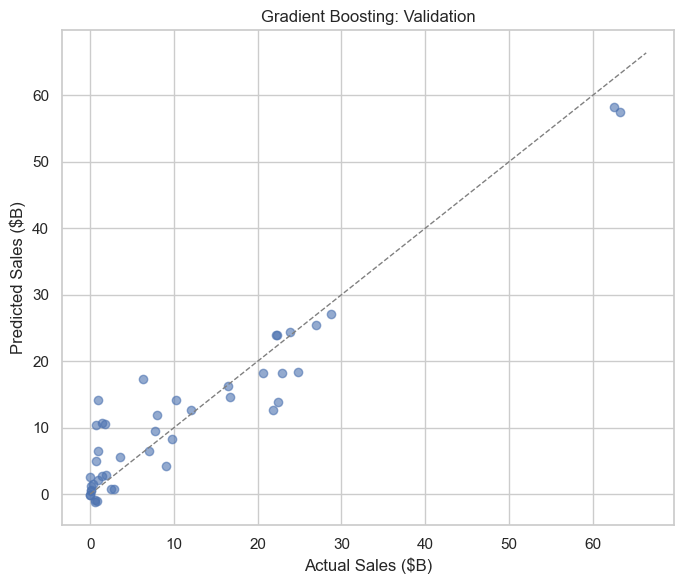

In [11]:
# Fit best Gradient Boosting on full training set
gbr_model = GradientBoostingRegressor(**best_gbr_params)
gbr_model.fit(X_train, y_train)

gbr_pred_valid = gbr_model.predict(X_valid)
gbr_pred_test = gbr_model.predict(X_test)

results.append(evaluate(y_valid, gbr_pred_valid, "M2: Gradient Boosting", "validation"))
results.append(evaluate(y_test, gbr_pred_test, "M2: Gradient Boosting", "test"))

display(pd.concat(results, ignore_index=True))
plot_actual_vs_predicted(y_valid, gbr_pred_valid, "Gradient Boosting: Validation")

## 8. ML Model 3: ElasticNet (Regularized Linear)

ElasticNet combines L1 (Lasso) and L2 (Ridge) penalties. It is a regularized linear model
that sits between the parametric OLS family and the tree-based ML models.

Including ElasticNet provides a genuinely different model family from the tree ensembles
and helps answer whether the nonlinearities captured by Random Forest and Gradient Boosting
meaningfully improve prediction over a regularized linear approach on the same feature set.

In [12]:
enet_configs = [
    {"alpha": 0.01, "l1_ratio": 0.5, "max_iter": 5000, "random_state": 42},
    {"alpha": 0.1, "l1_ratio": 0.5, "max_iter": 5000, "random_state": 42},
    {"alpha": 0.1, "l1_ratio": 0.2, "max_iter": 5000, "random_state": 42},
    {"alpha": 0.5, "l1_ratio": 0.5, "max_iter": 5000, "random_state": 42},
    {"alpha": 1.0, "l1_ratio": 0.8, "max_iter": 5000, "random_state": 42},
]

enet_cv = cv_evaluate(ElasticNet, enet_configs, "ElasticNet")
display(enet_cv)

best_enet_params = eval(enet_cv.iloc[0]["params"])
print(f"\nBest ElasticNet config: {best_enet_params}")

,model,params,cv_rmse_mean,cv_rmse_std
0,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.5, 'max_iter': 5...",7.8246,1.2809
1,ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 50...",8.9620,1.5132
2,ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.2, 'max_iter': 50...",9.1971,1.5497
3,ElasticNet,"{'alpha': 0.5, 'l1_ratio': 0.5, 'max_iter': 50...",10.1411,1.8146
4,ElasticNet,"{'alpha': 1.0, 'l1_ratio': 0.8, 'max_iter': 50...",10.5205,2.0074



Best ElasticNet config: {'alpha': 0.01, 'l1_ratio': 0.5, 'max_iter': 5000, 'random_state': 42}


,model,dataset,RMSE,MAE,R2,MAPE
0,M1: Random Forest,validation,5.5282,4.5064,0.8566,896.2600
1,M1: Random Forest,test,5.2544,4.1924,0.8582,860.8800
2,M2: Gradient Boosting,validation,4.7158,3.3238,0.8957,580.2000
3,M2: Gradient Boosting,test,5.4143,3.7543,0.8495,749.6400
4,M3: ElasticNet,validation,7.1261,5.0249,0.7618,"1,160.2700"
5,M3: ElasticNet,test,6.8343,5.1718,0.7601,"1,850.7600"


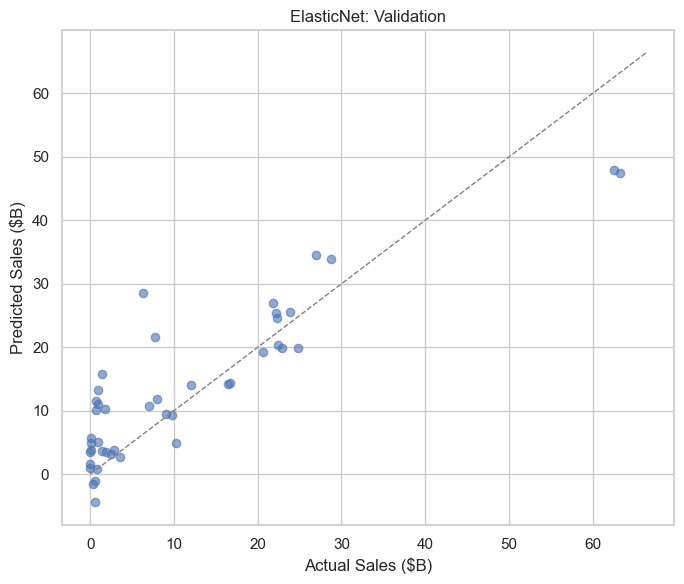

In [13]:
# Fit best ElasticNet on full training set
enet_model = ElasticNet(**best_enet_params)
enet_model.fit(X_train, y_train)

enet_pred_valid = enet_model.predict(X_valid)
enet_pred_test = enet_model.predict(X_test)

results.append(evaluate(y_valid, enet_pred_valid, "M3: ElasticNet", "validation"))
results.append(evaluate(y_test, enet_pred_test, "M3: ElasticNet", "test"))

display(pd.concat(results, ignore_index=True))
plot_actual_vs_predicted(y_valid, enet_pred_valid, "ElasticNet: Validation")

## 9. ML Model Comparison

In [14]:
comparison = pd.concat(results, ignore_index=True)
print("=== Full ML Benchmark ===\n")
display(comparison.sort_values(["dataset", "RMSE"]))

=== Full ML Benchmark ===



,model,dataset,RMSE,MAE,R2,MAPE
1,M1: Random Forest,test,5.2544,4.1924,0.8582,860.8800
3,M2: Gradient Boosting,test,5.4143,3.7543,0.8495,749.6400
5,M3: ElasticNet,test,6.8343,5.1718,0.7601,"1,850.7600"
2,M2: Gradient Boosting,validation,4.7158,3.3238,0.8957,580.2000
0,M1: Random Forest,validation,5.5282,4.5064,0.8566,896.2600
4,M3: ElasticNet,validation,7.1261,5.0249,0.7618,"1,160.2700"


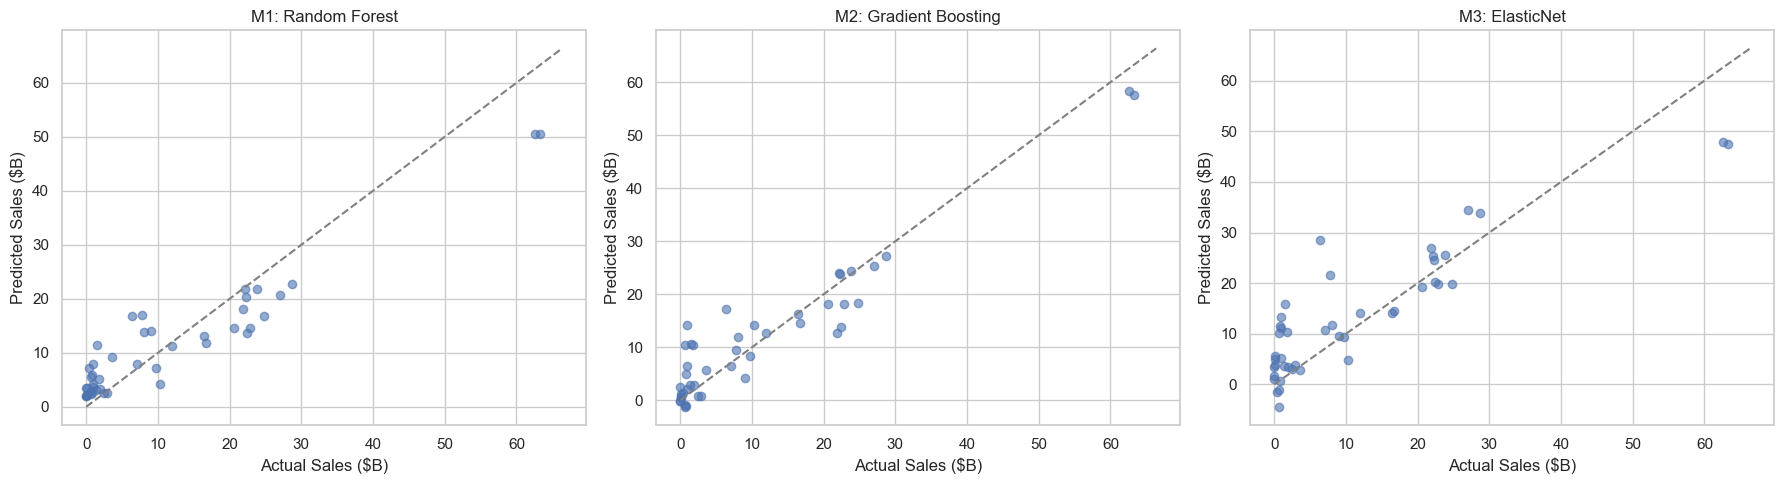


--- Model Selection ---
Compare the three ML models on validation RMSE and MAPE. The best ML model
will advance to the champion duel against the best parametric model.

If Gradient Boosting and Random Forest perform similarly, prefer Gradient
Boosting as it typically produces more stable predictions on structured
tabular data. If ElasticNet matches the tree models, that suggests the data
relationships are largely linear and the parametric models may be sufficient.



In [15]:
# Side-by-side validation comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ("M1: Random Forest", rf_pred_valid),
    ("M2: Gradient Boosting", gbr_pred_valid),
    ("M3: ElasticNet", enet_pred_valid),
]

for i, (name, pred) in enumerate(models_preds):
    axes[i].scatter(y_valid, pred, alpha=0.6)
    lims = [0, max(y_valid.max(), pred.max()) * 1.05]
    axes[i].plot(lims, lims, "--", color="gray")
    axes[i].set_xlabel("Actual Sales ($B)")
    axes[i].set_ylabel("Predicted Sales ($B)")
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

print('''
--- Model Selection ---
Compare the three ML models on validation RMSE and MAPE. The best ML model
will advance to the champion duel against the best parametric model.

If Gradient Boosting and Random Forest perform similarly, prefer Gradient
Boosting as it typically produces more stable predictions on structured
tabular data. If ElasticNet matches the tree models, that suggests the data
relationships are largely linear and the parametric models may be sufficient.
''')

## 10. Feature Importance Analysis

While ML models do not produce interpretable coefficients like parametric models, we can
assess which features drive predictions using permutation importance. This shuffles each
feature and measures the increase in prediction error, revealing which features the model
relies on most.

In [16]:
# Use the best tree model for importance analysis
# Determine best ML model from comparison
valid_results = comparison[comparison["dataset"] == "validation"].sort_values("RMSE")
best_ml_name = valid_results.iloc[0]["model"]
print(f"Best ML model: {best_ml_name}")

if "Random Forest" in best_ml_name:
    best_ml_model = rf_model
    best_ml_pred_valid = rf_pred_valid
    best_ml_pred_test = rf_pred_test
elif "Gradient Boosting" in best_ml_name:
    best_ml_model = gbr_model
    best_ml_pred_valid = gbr_pred_valid
    best_ml_pred_test = gbr_pred_test
else:
    best_ml_model = enet_model
    best_ml_pred_valid = enet_pred_valid
    best_ml_pred_test = enet_pred_test

Best ML model: M2: Gradient Boosting


In [17]:
# Permutation importance on validation set
perm = permutation_importance(best_ml_model, X_valid, y_valid, n_repeats=20, random_state=42)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(f"=== Permutation Importance ({best_ml_name}) ===\n")
display(importance_df.head(15))

=== Permutation Importance (M2: Gradient Boosting) ===



,feature,importance_mean,importance_std
16,agent_ Lipitor,0.3184,0.0821
2,direct_to_consumer_ad,0.1940,0.0491
3,log_detailing,0.1285,0.0309
1,detailing,0.1051,0.0250
4,log_dtca,0.0967,0.0263
21,agent_ Paxil CR,0.0135,0.0107
12,agent_ Crestor,0.0129,0.0044
11,agent_ Celexa,0.0096,0.0161
29,agent_ Zoloft,0.0090,0.0049
27,agent_ Prozac Weekly,0.0053,0.0044


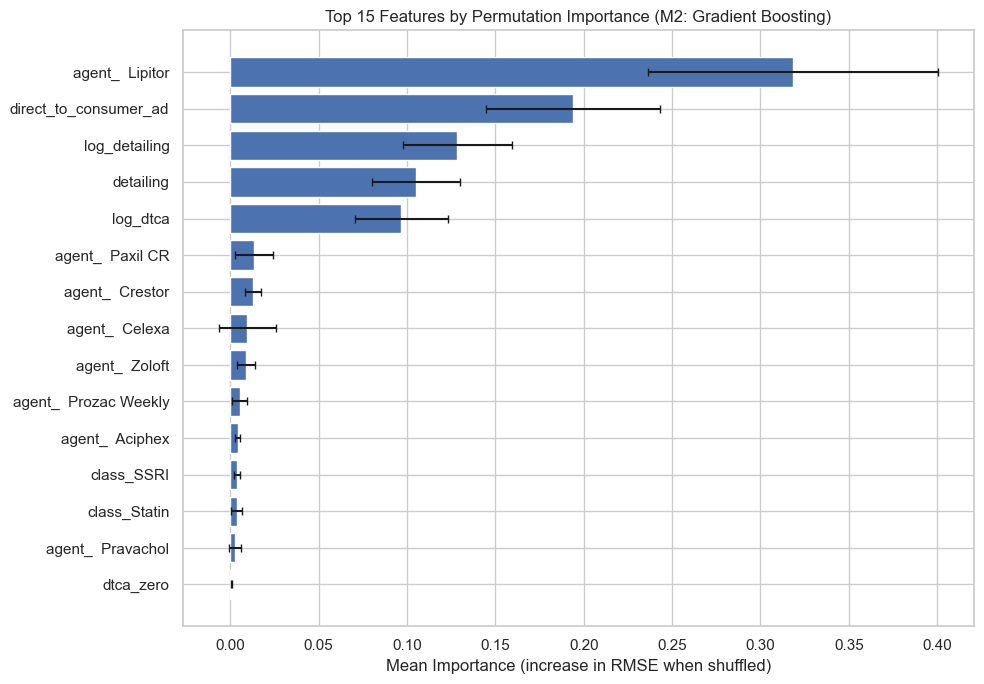


--- Interpretation ---
Features with high importance are the ones the model relies on most for
accurate predictions. Compare this ranking with the parametric model
coefficients from Notebook 02:

- If agent dummies dominate, it confirms that brand identity drives sales
  more than marketing variables (consistent with the EDA finding that
  baselines vary 50x across agents).
- If log_detailing ranks above log_dtca, it aligns with the parametric
  finding that detailing is the stronger marketing lever overall.
- If year ranks high, it confirms the temporal dynamics the parametric
  model captures via C(Year) fixed effects.

This comparison helps validate that the parametric model is capturing
the right relationships, even if the ML model achieves slightly better
prediction accuracy.



In [18]:
# Plot top 15 features
top_imp = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 7))
plt.barh(top_imp["feature"], top_imp["importance_mean"],
         xerr=top_imp["importance_std"], capsize=3)
plt.title(f"Top 15 Features by Permutation Importance ({best_ml_name})")
plt.xlabel("Mean Importance (increase in RMSE when shuffled)")
plt.tight_layout()
plt.show()

print('''
--- Interpretation ---
Features with high importance are the ones the model relies on most for
accurate predictions. Compare this ranking with the parametric model
coefficients from Notebook 02:

- If agent dummies dominate, it confirms that brand identity drives sales
  more than marketing variables (consistent with the EDA finding that
  baselines vary 50x across agents).
- If log_detailing ranks above log_dtca, it aligns with the parametric
  finding that detailing is the stronger marketing lever overall.
- If year ranks high, it confirms the temporal dynamics the parametric
  model captures via C(Year) fixed effects.

This comparison helps validate that the parametric model is capturing
the right relationships, even if the ML model achieves slightly better
prediction accuracy.
''')

## 11. Retrain Best ML Model on Train + Validation

Same approach as Notebook 02: retrain the selected model on 2013-2022 and evaluate on
the 2023-2024 holdout.

,model,dataset,RMSE,MAE,R2,MAPE
0,Best ML: M2: Gradient Boosting (retrained),test,3.4707,2.3366,0.9381,272.4000


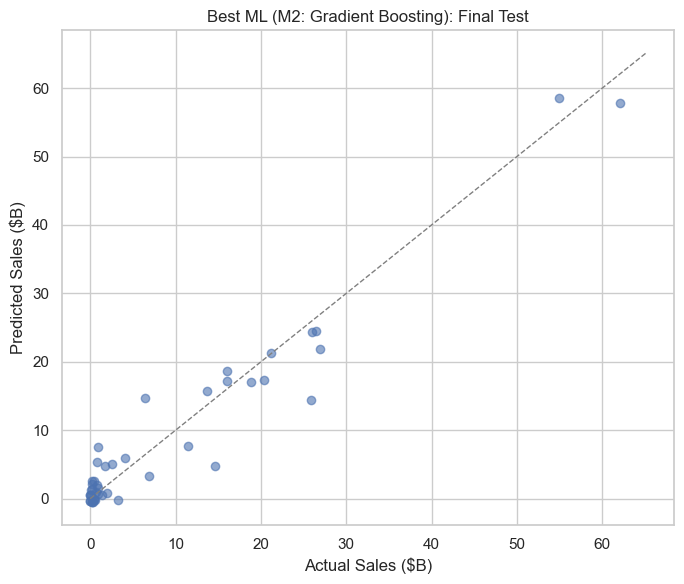

This model advances to the champion duel against the best parametric model.


In [19]:
train_valid_df = df[df["year"] <= 2022].copy()

X_train_valid, _ = prepare_features(train_valid_df)
y_train_valid = train_valid_df[target].values

# Retrain best ML model
if "Random Forest" in best_ml_name:
    best_ml_retrained = RandomForestRegressor(**best_rf_params)
elif "Gradient Boosting" in best_ml_name:
    best_ml_retrained = GradientBoostingRegressor(**best_gbr_params)
else:
    best_ml_retrained = ElasticNet(**best_enet_params)

best_ml_retrained.fit(X_train_valid, y_train_valid)
ml_final_pred = best_ml_retrained.predict(X_test)

final_metrics = evaluate(y_test, ml_final_pred, f"Best ML: {best_ml_name} (retrained)", "test")
display(final_metrics)

plot_actual_vs_predicted(y_test, ml_final_pred, f"Best ML ({best_ml_name}): Final Test")

print("This model advances to the champion duel against the best parametric model.")

=== Per-Class Test Performance — M2: Gradient Boosting (retrained) ===



,N,RMSE ($B),MAE ($B),R²,wMAPE (%),Mean Actual ($B)
Class,,,,,,
PPI,10,4.8510,3.3760,0.7236,23.9000,14.1000
SSRI,18,2.0650,1.5680,0.9454,22.5000,4.5500
Statin,16,3.6910,2.5520,0.9615,23.5000,10.5400


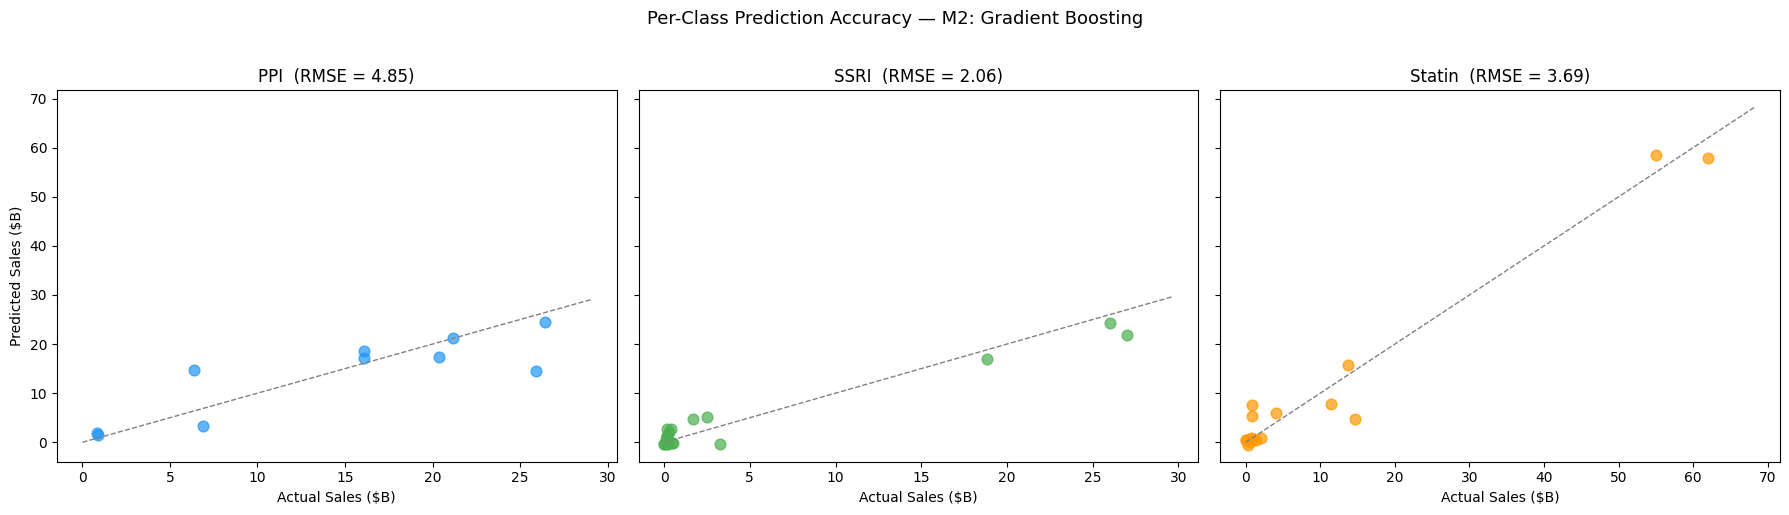


--- Per-Class Insights ---
Compare RMSE and R² across the three drug categories. Key questions:
  • Which class does the model predict best / worst?
  • Is error concentrated in high-sales or low-sales agents within a class?
  • Does the class with highest DTCA spend show different prediction quality?

These patterns inform the trade-off discussion: if the ML model struggles on
a particular class, and the parametric model handles it well (or vice versa),
that difference shapes which model we trust for class-level inference.



In [24]:
# ============================================================================
# ADD THIS AFTER SECTION 11 (Retrain Best ML Model on Train + Validation)
# AND BEFORE SECTION 12 (Champion Duel Preview)
#
# New Section: "11b. Per-Class Performance Breakdown"
# ============================================================================

# --- Markdown Cell ---
# ## 11b. Per-Class Performance Breakdown
#
# Global metrics mask important differences in how well the model predicts
# across drug categories. Since the assignment asks us to explore how effects
# differ across dimensions of the data, we evaluate the retrained best ML
# model separately for each drug class (PPI, SSRI, Statin) on the final
# test set (2023–2024).

# --- Code Cell ---
def evaluate_by_group(test_data, y_pred, group_col="class"):
    """Compute RMSE, MAE, R2 per group on original dollar scale."""
    eval_df = test_data[[group_col, "actual_sales"]].copy()
    eval_df["predicted"] = np.maximum(y_pred, 0)
    eval_df["error"] = eval_df["actual_sales"] - eval_df["predicted"]
    eval_df["sq_error"] = eval_df["error"] ** 2
    eval_df["abs_error"] = np.abs(eval_df["error"])

    rows = []
    for name, grp in eval_df.groupby(group_col):
        n = len(grp)
        rmse = np.sqrt(grp["sq_error"].mean())
        mae = grp["abs_error"].mean()
        ss_res = grp["sq_error"].sum()
        ss_tot = ((grp["actual_sales"] - grp["actual_sales"].mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        # Weighted MAPE: exclude near-zero actuals
        mask = grp["actual_sales"] > 0.5  # $0.5B threshold
        wmape = (
            grp.loc[mask, "abs_error"].sum() / grp.loc[mask, "actual_sales"].sum() * 100
            if mask.sum() > 0 else float("nan")
        )
        rows.append({
            "Class": name,
            "N": n,
            "RMSE ($B)": round(rmse, 3),
            "MAE ($B)": round(mae, 3),
            "R²": round(r2, 4),
            "wMAPE (%)": round(wmape, 1),
            "Mean Actual ($B)": round(grp["actual_sales"].mean(), 2),
        })

    return pd.DataFrame(rows).set_index("Class")


class_breakdown = evaluate_by_group(test_df, ml_final_pred, group_col="class")

print(f"=== Per-Class Test Performance — {best_ml_name} (retrained) ===\n")
display(class_breakdown)

# --- Code Cell ---
# Visualize: actual vs predicted colored by class
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
classes = sorted(test_df["class"].unique())
colors = {"PPI": "#2196F3", "SSRI": "#4CAF50", "Statin": "#FF9800"}

for i, cls in enumerate(classes):
    mask = test_df["class"] == cls
    y_true_cls = test_df.loc[mask, "actual_sales"].values
    y_pred_cls = ml_final_pred[mask.values]

    axes[i].scatter(y_true_cls, y_pred_cls, alpha=0.7, color=colors.get(cls, "gray"), s=60)
    lims = [0, max(y_true_cls.max(), y_pred_cls.max()) * 1.1]
    axes[i].plot(lims, lims, "--", color="gray", linewidth=1)
    axes[i].set_xlabel("Actual Sales ($B)")
    if i == 0:
        axes[i].set_ylabel("Predicted Sales ($B)")
    axes[i].set_title(f"{cls}  (RMSE = {class_breakdown.loc[cls, 'RMSE ($B)']:.2f})")

plt.suptitle(f"Per-Class Prediction Accuracy — {best_ml_name}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('''
--- Per-Class Insights ---
Compare RMSE and R² across the three drug categories. Key questions:
  • Which class does the model predict best / worst?
  • Is error concentrated in high-sales or low-sales agents within a class?
  • Does the class with highest DTCA spend show different prediction quality?

These patterns inform the trade-off discussion: if the ML model struggles on
a particular class, and the parametric model handles it well (or vice versa),
that difference shapes which model we trust for class-level inference.
''')

## 12. Champion Duel Preview

Load the parametric benchmark from Notebook 02 and compare side-by-side with the ML results.

In [20]:
# Load parametric results
try:
    parametric_bench = pd.read_csv("data/parametric_benchmark.csv")
    print("=== Parametric Benchmark (from Notebook 02) ===\n")
    display(parametric_bench.sort_values(["dataset", "RMSE"]))
except FileNotFoundError:
    print("Parametric benchmark not found. Run Notebook 02 first.")
    parametric_bench = None

=== Parametric Benchmark (from Notebook 02) ===



,model,dataset,RMSE,MAE,R2,MAPE
1,M1: Pooled OLS,test,9.4357,4.6965,0.5428,187.8100
0,M1: Pooled OLS,validation,10.9340,5.7500,0.4391,395.2200


In [21]:
# Combined comparison
if parametric_bench is not None:
    combined = pd.concat([parametric_bench, comparison], ignore_index=True)
    print("=== Combined Benchmark: Parametric vs ML ===\n")

    for ds in ["validation", "test"]:
        print(f"\n--- {ds.upper()} ---")
        display(combined[combined["dataset"] == ds].sort_values("RMSE"))
else:
    print("Combined comparison will be available after running Notebook 02.")

=== Combined Benchmark: Parametric vs ML ===


--- VALIDATION ---


,model,dataset,RMSE,MAE,R2,MAPE
4,M2: Gradient Boosting,validation,4.7158,3.3238,0.8957,580.2000
2,M1: Random Forest,validation,5.5282,4.5064,0.8566,896.2600
6,M3: ElasticNet,validation,7.1261,5.0249,0.7618,"1,160.2700"
0,M1: Pooled OLS,validation,10.9340,5.7500,0.4391,395.2200



--- TEST ---


,model,dataset,RMSE,MAE,R2,MAPE
3,M1: Random Forest,test,5.2544,4.1924,0.8582,860.8800
5,M2: Gradient Boosting,test,5.4143,3.7543,0.8495,749.6400
7,M3: ElasticNet,test,6.8343,5.1718,0.7601,"1,850.7600"
1,M1: Pooled OLS,test,9.4357,4.6965,0.5428,187.8100


## 13. ML Modeling Summary

In [22]:
print('''
=== ML Modeling Summary ===

MODEL FAMILY:
  Model 1 (Random Forest): Ensemble of decision trees trained on bootstrap
    samples. Captures nonlinearities and interactions automatically.

  Model 2 (Gradient Boosting): Sequential ensemble where each tree corrects
    the errors of the previous ensemble. Typically strongest on tabular data.

  Model 3 (ElasticNet): Regularized linear model with L1+L2 penalties.
    Provides a bridge between the parametric OLS family and nonlinear ML
    models, helping isolate whether nonlinearity adds predictive value.

BEST ML MODEL:
  [Update after reviewing Section 9 results]
  Selected based on validation RMSE.

FEATURE IMPORTANCE FINDINGS:
  [Update after reviewing Section 10 results]
  - Which features dominate predictions?
  - Does the ranking align with parametric coefficient magnitudes?

CHAMPION DUEL PREVIEW:
  [Update after reviewing Section 12 results]
  - Does the best ML model materially outperform the best parametric model?
  - If the gap is small, the parametric model is preferred because it
    provides direct elasticity estimates and interpretable coefficients.
  - If the gap is large, the ML model offers better predictive accuracy but
    at the cost of interpretability for ROI and budget allocation decisions.

TRADE-OFF DISCUSSION (for the report):
  ML Advantage: Flexible nonlinearities, automatic interaction discovery,
    potentially lower prediction error.
  Parametric Advantage: Direct elasticity coefficients, transparent response
    curves, defensible managerial recommendations, ROI estimation.
  For an assignment that values inference, estimation, and actionable insights,
  the parametric model is preferred unless ML is materially more accurate.
''')


=== ML Modeling Summary ===

MODEL FAMILY:
  Model 1 (Random Forest): Ensemble of decision trees trained on bootstrap
    samples. Captures nonlinearities and interactions automatically.

  Model 2 (Gradient Boosting): Sequential ensemble where each tree corrects
    the errors of the previous ensemble. Typically strongest on tabular data.

  Model 3 (ElasticNet): Regularized linear model with L1+L2 penalties.
    Provides a bridge between the parametric OLS family and nonlinear ML
    models, helping isolate whether nonlinearity adds predictive value.

BEST ML MODEL:
  [Update after reviewing Section 9 results]
  Selected based on validation RMSE.

FEATURE IMPORTANCE FINDINGS:
  [Update after reviewing Section 10 results]
  - Which features dominate predictions?
  - Does the ranking align with parametric coefficient magnitudes?

CHAMPION DUEL PREVIEW:
  [Update after reviewing Section 12 results]
  - Does the best ML model materially outperform the best parametric model?
  - If the g

In [23]:
comparison.to_csv("data/ml_benchmark.csv", index=False)
print("Saved: data/ml_benchmark.csv")

# Save best ML test predictions for potential downstream use
ml_test_results = test_df[["class", "agent", "year", "actual_sales"]].copy()
ml_test_results["ml_predicted"] = ml_final_pred
ml_test_results.to_csv("data/ml_predictions.csv", index=False)
print("Saved: data/ml_predictions.csv")

Saved: data/ml_benchmark.csv
Saved: data/ml_predictions.csv
